In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report

In [2]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 838s 5us/step


In [3]:
X_train.shape

(50000, 32, 32, 3)

In [4]:
X_test.shape

(10000, 32, 32, 3)

In [5]:
y_train.shape

(50000, 1)

In [6]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [7]:
y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

In [8]:
y_train.shape

(50000,)

In [9]:
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [10]:
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

In [11]:
def plot_sample(X, y, index):
    plt.figure(figsize=(5, 3))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])
    plt.axis("off")
    plt.show()

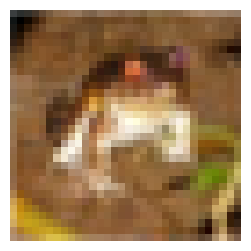

In [12]:
plot_sample(X_train, y_train, 0)

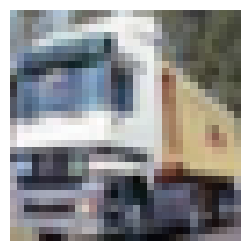

In [13]:
plot_sample(X_train, y_train, 1)

In [14]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [15]:
X_train[0].min(), X_train[0].max()

(np.float64(0.0), np.float64(1.0))

In [16]:
ann = models.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),
    layers.Dense(3000, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
ann.compile(
    optimizer='SGD',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
ann.fit(X_train, y_train, epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 153s 97ms/step - accuracy: 0.3562 - loss: 1.8120
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 146s 93ms/step - accuracy: 0.4242 - loss: 1.6243
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 147s 94ms/step - accuracy: 0.4579 - loss: 1.5417
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 208s 98ms/step - accuracy: 0.4767 - loss: 1.4843
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 91ms/step - accuracy: 0.4947 - loss: 1.4322


In [19]:
y_pred_ann = ann.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step


In [20]:
y_pred_ann_classes = np.argmax(y_pred_ann, axis=1)

In [21]:
print(
    "Classification Report:\n",
    classification_report(y_test, y_pred_ann_classes, target_names=classes)
)

Classification Report:
               precision    recall  f1-score   support

    airplane       0.66      0.44      0.53      1000
  automobile       0.68      0.56      0.61      1000
        bird       0.46      0.18      0.26      1000
         cat       0.36      0.17      0.23      1000
        deer       0.56      0.26      0.35      1000
         dog       0.29      0.59      0.39      1000
        frog       0.53      0.55      0.54      1000
       horse       0.35      0.76      0.48      1000
        ship       0.55      0.70      0.62      1000
       truck       0.66      0.44      0.53      1000

    accuracy                           0.47     10000
   macro avg       0.51      0.47      0.45     10000
weighted avg       0.51      0.47      0.45     10000



In [22]:
cnn = models.Sequential([
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu',
        input_shape=(32, 32, 3)
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation='relu'
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),

    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
history = cnn.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 48ms/step - accuracy: 0.4977 - loss: 1.4053 - val_accuracy: 0.6153 - val_loss: 1.1189
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 48ms/step - accuracy: 0.6307 - loss: 1.0602 - val_accuracy: 0.6504 - val_loss: 1.0047
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.6748 - loss: 0.9303 - val_accuracy: 0.6746 - val_loss: 0.9491
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 48ms/step - accuracy: 0.7040 - loss: 0.8451 - val_accuracy: 0.6753 - val_loss: 0.9534
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 47ms/step - accuracy: 0.7318 - loss: 0.7736 - val_accuracy: 0.6790 - val_loss: 0.9340
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.7519 - loss: 0.7156 - val_accuracy: 0.6958 - val_loss: 0.9013
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.7707 - loss: 0.6606 - val_accuracy: 0.6961 - val_loss: 0.9020
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.7834 -

In [25]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.6988 - loss: 1.0043


[1.0042792558670044, 0.6988000273704529]

In [26]:
y_pred = cnn.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step


In [27]:
y_classes = [np.argmax(element) for element in y_pred]

In [28]:
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(1), np.int64(0), np.int64(6)]

In [29]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

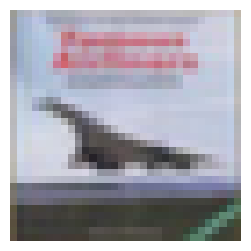

In [30]:
plot_sample(X_test, y_test, 3)

In [31]:
classes[y_classes[3]]

'airplane'

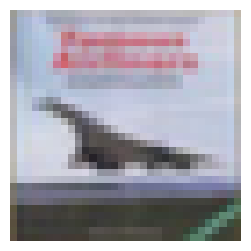

'airplane'

In [32]:
y_classes = [np.argmax(element) for element in y_pred]

y_classes[:5]

y_test[:5]

plot_sample(X_test, y_test, 3)

classes[y_classes[3]]

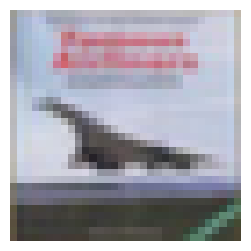

In [33]:
plot_sample(X_test, y_test, 3)

In [34]:
classes[y_classes[3]]

'airplane'

In [35]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6988 - loss: 1.0043


[1.0042792558670044, 0.6988000273704529]

In [36]:
test_loss, test_accuracy = cnn.evaluate(X_test, y_test)

print("CNN Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.6988 - loss: 1.0043
CNN Test Accuracy: 0.6988000273704529
